# CG4002: Voice PyTorch 1D-CNN Trainer & HLS Export

## Notes
1. Augment train only
2. Normalise from train stats only


In [16]:
# Single package-install cell
# %pip install numpy pandas scikit-learn matplotlib seaborn torchaudio pysoundfile


In [17]:
import sys
import importlib
from pathlib import Path

TOOLS_DIR = Path('../tools').resolve()
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import voice_feature_pipeline
importlib.reload(voice_feature_pipeline)

from voice_feature_pipeline import (
    build_feature_set_from_manifest as build_deployment_feature_set,
    scan_audio_roots,
)

In [18]:
# Single import/config cell
import copy  # Deep-copy best model checkpoint parameters.
import random  # Seed Python RNG for reproducible data ops.
import re  # Match dated dataset folder names with regex.
import secrets  # Generate fresh split seeds when the test split should reshuffle each run.
import subprocess  # Run offline dataset cleanup when requested.
import sys  # Reuse the active notebook Python for helper scripts.
from datetime import datetime  # Parse date folder strings to datetime objects.
from pathlib import Path  # OS-safe path joins and filesystem traversal.

import importlib  # Reload local helper modules after notebook-side edits.
import matplotlib.pyplot as plt  # Plot confusion matrices and other figures.
import numpy as np  # Numeric arrays and .npy serialization.
import pandas as pd  # Build and persist file manifests.
import seaborn as sns  # Styled heatmaps for confusion matrices.
import torch  # Core tensors, device selection, and model execution.
import torch.nn as nn  # Layer modules (Conv1d, Linear, activation wrappers).
import torch.nn.functional as F  # Functional ops for HLS-like forward simulation.
import torch.optim as optim  # Optimizers for training.
from sklearn.metrics import accuracy_score, confusion_matrix  # Accuracy + confusion metrics.
from sklearn.model_selection import train_test_split  # Stratified split utilities.
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler  # Batch loading utilities.

TOOLS_DIR = Path('../tools').resolve()
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

for module_name in ('voice_cnn_training', 'voice_feature_pipeline', 'voice_model_metadata'):
    sys.modules.pop(module_name, None)

import voice_cnn_training
import voice_feature_pipeline
import voice_model_metadata

importlib.reload(voice_cnn_training)
importlib.reload(voice_feature_pipeline)
importlib.reload(voice_model_metadata)

from voice_cnn_training import (
    FocalCrossEntropyLoss,
    assert_hls_state_shapes,
    build_hls_export_state_dict,
    build_voice_model,
    is_hls_shape_compatible_model,
    mixup_batch,
    voice_hls_subdir_for_variant,
)
from voice_feature_pipeline import (
    build_feature_set_from_manifest as build_deployment_feature_set,
    discover_dashboard_voice_roots,
    scan_audio_roots,
)
from voice_model_metadata import (
    DEFAULT_TRAINING_VOICE_PREPROCESS_KWARGS,
    labels_from_class_map,
    save_voice_labels,
    save_voice_preprocess_config,
)

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Core settings
SAMPLE_RATE = 16000
N_MFCC = 40
TARGET_FRAMES = 50
NUM_CLASSES = 6
MODEL_VARIANT = 'experimental'  # 'deployed' matches current HLS/IP; 'experimental' uses a modest 20/40-channel 2-conv model.
VOICE_HLS_SUBDIR = voice_hls_subdir_for_variant(MODEL_VARIANT)
BATCH_SIZE = 16
EPOCHS = 40
PRETRAIN_EPOCHS = 20  # Kept for reference when synthetic pretraining is enabled.
FINETUNE_EPOCHS = 20  # Kept for reference when synthetic pretraining is enabled.
LEARNING_RATE = 5e-4
FINETUNE_LEARNING_RATE = 3e-4  # Kept for reference when synthetic pretraining is enabled.
WEIGHT_DECAY = 2e-3
VAL_SIZE = 0.2
TEST_SIZE = 0.2
RANDOMISE_SPLIT_EACH_RUN = True
SPLIT_SEED = None  # Ignored when RANDOMISE_SPLIT_EACH_RUN=True. Set an int for a fixed split.
EARLY_STOPPING_PATIENCE = 8
PRINT_EVERY_EPOCH = True
LABEL_SMOOTHING = 0.0  # Mixup already softens targets; extra smoothing hurt the saved split in quick checks.
DROPOUT_P = 0.15
TRAIN_AUG_MULTIPLIER = 6  # Logical samples per epoch = train_seed * multiplier.
CLIPS_PER_SPEAKER = 5
MIN_SPEAKERS_PER_SPLIT = 2
CLASS_WEIGHT_POWER = 1.0
LOSS_CLASS_WEIGHT_POWER = 0.0  # Sampler already handles imbalance; keep loss nearly neutral.
DASHBOARD_SAMPLE_WEIGHT = 2.5
OLD_SOURCE_SAMPLE_WEIGHT = 1.25  # Keep some emphasis on noisier old clips without letting them dominate training.
MIXUP_ALPHA = 0.0  # Disabled by default; mixup blurred the class boundaries too much on this dataset.
FOCAL_GAMMA = 1.5
BN_MOMENTUM = 0.05
BN_EPS = 1e-3
HARD_CLASS_SAMPLE_BOOSTS = {
    'Charizard': 1.2,
    'Greninja': 1.25,
    'Lugia': 1.1,
    'Mewtwo': 1.35,
    'Pikachu': 1.3,
}  # Recall-oriented sampler boosts from the latest confusion matrix; Bulbasaur stays at 1.0.
VOICE_PREPROCESS_KWARGS = dict(DEFAULT_TRAINING_VOICE_PREPROCESS_KWARGS)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print('Using device:', device)


Using device: mps


## 0) Dataset path selection

Check this cell before rebuilding any voice artefacts.


In [19]:
# Voice dataset selection and derived input source settings.
AUDIO_ROOT = Path('../data/audio')
COMBINED_AUDIO_ROOT = AUDIO_ROOT / '20260406'
COMBINED_AUDIO_LABEL = '20260406_combined'
BASE_AUDIO_SOURCES = [
    COMBINED_AUDIO_ROOT / 'synthetic',
    COMBINED_AUDIO_ROOT / 'old',
    COMBINED_AUDIO_ROOT / 'new',
]
DASHBOARD_DATA_ROOT = Path('../dashboard/data')
INCLUDE_DASHBOARD_VOICE_DATA = True
AUDIO_DIR_OVERRIDE = None  # Optional single-source override for ad-hoc experiments.
CLEANED_AUDIO_DIR_OVERRIDE = None  # Optional QA folder only; raw audio is recommended for deployment parity.
USE_CLEANED_AUDIO = False  # Keep False for parity. True would trim/normalise twice during feature rebuild.
RUN_AUDIO_CLEANUP = False  # Optional QA-only export of cleaned wav files from raw audio.
PREPROCESS_SCRIPT = Path('../tools/preprocess_voice_audio.py').resolve()

RAW_AUDIO_DIR = AUDIO_DIR_OVERRIDE if AUDIO_DIR_OVERRIDE is not None else None

if RAW_AUDIO_DIR is None:
    missing_sources = [path for path in BASE_AUDIO_SOURCES if not path.exists()]
    if missing_sources:
        raise FileNotFoundError(
            'Combined audio sources missing. Rebuild them with tools/build_voice_dataset.py: '
            + ', '.join(str(path) for path in missing_sources)
        )

    COMBINED_AUDIO_SOURCES = list(BASE_AUDIO_SOURCES)
    if INCLUDE_DASHBOARD_VOICE_DATA:
        dashboard_sources = discover_dashboard_voice_roots(
            DASHBOARD_DATA_ROOT,
            required_class_names={'bulbasaur', 'charizard', 'greninja', 'lugia', 'mewtwo', 'pikachu'},
        )
        COMBINED_AUDIO_SOURCES.extend(dashboard_sources)
    else:
        dashboard_sources = []

    print('Using combined raw audio sources:', [str(path) for path in COMBINED_AUDIO_SOURCES])
    print('Dashboard voice sources discovered:', [str(path) for path in dashboard_sources])
    print('Split policy: random stratified file split')
else:
    print('Using single-source override:', RAW_AUDIO_DIR)
    if USE_CLEANED_AUDIO:
        print('Cleaned-audio QA mode enabled.')


Using combined raw audio sources: ['../data/audio/20260406/synthetic', '../data/audio/20260406/old', '../data/audio/20260406/new', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260331T032157/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260406T045617/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260406T050117/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T024943/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T025740/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T032141/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T040800/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T042029/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T042800/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/202

In [20]:
# Optional offline cleanup step for listening checks and QA only.
if USE_CLEANED_AUDIO and RAW_AUDIO_DIR is None:
    raise RuntimeError('USE_CLEANED_AUDIO requires AUDIO_DIR_OVERRIDE so there is one raw source to clean.')

if RAW_AUDIO_DIR is not None:
    CLEANED_AUDIO_DIR = (
        CLEANED_AUDIO_DIR_OVERRIDE
        if CLEANED_AUDIO_DIR_OVERRIDE is not None
        else RAW_AUDIO_DIR.parent / f'{RAW_AUDIO_DIR.name}_clean'
    )
    if USE_CLEANED_AUDIO:
        print('Warning: USE_CLEANED_AUDIO=True breaks strict deployment parity by reusing already-cleaned clips.')
        if RUN_AUDIO_CLEANUP or not CLEANED_AUDIO_DIR.exists():
            if not PREPROCESS_SCRIPT.exists():
                raise FileNotFoundError(f'Preprocess script not found: {PREPROCESS_SCRIPT}')
            cmd = [
                sys.executable,
                str(PREPROCESS_SCRIPT),
                '--input',
                str(RAW_AUDIO_DIR),
                '--output',
                str(CLEANED_AUDIO_DIR),
            ]
            print('Running audio cleanup:', ' '.join(cmd))
            subprocess.run(cmd, check=True)
        else:
            print('Using existing cleaned audio folder:', CLEANED_AUDIO_DIR)
        AUDIO_DIR = CLEANED_AUDIO_DIR
    else:
        AUDIO_DIR = RAW_AUDIO_DIR
        print('Using raw audio folder without cleanup:', AUDIO_DIR)
else:
    AUDIO_DIR = None

ARTIFACT_AUDIO_DIR = AUDIO_ROOT / COMBINED_AUDIO_LABEL if RAW_AUDIO_DIR is None else AUDIO_DIR
ARTIFACT_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

if RAW_AUDIO_DIR is None:
    print('Using combined raw audio sources:', [str(path) for path in COMBINED_AUDIO_SOURCES])
else:
    print('Active audio folder:', AUDIO_DIR)
print('Artifact output folder:', ARTIFACT_AUDIO_DIR)

MANIFEST_CSV = ARTIFACT_AUDIO_DIR / 'voice_manifest.csv'
TRAIN_MANIFEST_CSV = ARTIFACT_AUDIO_DIR / 'voice_train_manifest.csv'
VAL_MANIFEST_CSV = ARTIFACT_AUDIO_DIR / 'voice_val_manifest.csv'
TEST_MANIFEST_CSV = ARTIFACT_AUDIO_DIR / 'voice_test_manifest.csv'
FEATURES_NPY = ARTIFACT_AUDIO_DIR / 'voice_features.npy'
LABELS_NPY = ARTIFACT_AUDIO_DIR / 'voice_labels.npy'
TRAIN_NPY = ARTIFACT_AUDIO_DIR / 'voice_X_train.npy'
TEST_NORM_NPY = ARTIFACT_AUDIO_DIR / 'voice_X_test_norm.npy'
YTRAIN_NPY = ARTIFACT_AUDIO_DIR / 'voice_y_train.npy'
YTEST_NPY = ARTIFACT_AUDIO_DIR / 'voice_y_test.npy'
BOARD_TEST_NPY = ARTIFACT_AUDIO_DIR / 'voice_X_test.npy'
MEAN_NPY = ARTIFACT_AUDIO_DIR / 'voice_mean.npy'
STD_NPY = ARTIFACT_AUDIO_DIR / 'voice_std.npy'
WEIGHTS_H_PATH = ARTIFACT_AUDIO_DIR / 'voice_cnn_weights.h'
VOICE_DASHBOARD_CHECKPOINT_PT = ARTIFACT_AUDIO_DIR / 'voice_dashboard_model.pt'
LABELS_JSON = ARTIFACT_AUDIO_DIR / 'voice_labels.json'
PREPROCESS_CONFIG_JSON = ARTIFACT_AUDIO_DIR / 'voice_preprocess_config.json'
TEST_PREDICTIONS_CSV = ARTIFACT_AUDIO_DIR / 'voice_test_predictions.csv'


Using combined raw audio sources: ['../data/audio/20260406/synthetic', '../data/audio/20260406/old', '../data/audio/20260406/new', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260331T032157/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260406T045617/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260406T050117/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T024943/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T025740/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T032141/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T040800/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T042029/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/20260407T042800/voice', '/Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/dashboard/data/202

## 1) Data scan -> MFCC base features


In [21]:
# Build one manifest across the dated raw datasets.
if RAW_AUDIO_DIR is None:
    manifest_df, CLASS_MAP = scan_audio_roots(COMBINED_AUDIO_SOURCES, clips_per_speaker=CLIPS_PER_SPEAKER)
else:
    manifest_df, CLASS_MAP = scan_audio_roots([AUDIO_DIR], clips_per_speaker=CLIPS_PER_SPEAKER)
manifest_df.to_csv(MANIFEST_CSV, index=False)
ACTIVE_LABELS = labels_from_class_map(CLASS_MAP)
save_voice_labels(ACTIVE_LABELS, LABELS_JSON)
save_voice_preprocess_config(VOICE_PREPROCESS_KWARGS, PREPROCESS_CONFIG_JSON)
print('Samples:', len(manifest_df))
print('Class map:', CLASS_MAP)
print('Active labels:', ACTIVE_LABELS)
print('Source counts:', manifest_df['source'].value_counts().sort_index().to_dict())
print('Saved metadata:', LABELS_JSON, PREPROCESS_CONFIG_JSON)
print('Preprocess config:', VOICE_PREPROCESS_KWARGS)

# Build features with the exact deployment preprocessor so training and deployment stay aligned.
# For strict parity, point the manifest at raw dataset folders instead of *_clean folders.
X_base, y_base = build_deployment_feature_set(
    manifest_df,
    sample_rate=SAMPLE_RATE,
    preprocess_kwargs=VOICE_PREPROCESS_KWARGS,
)
np.save(FEATURES_NPY, X_base)
np.save(LABELS_NPY, y_base)

print('X_base:', X_base.shape, 'y_base:', y_base.shape)
print('Class counts:', {int(i): int((y_base == i).sum()) for i in np.unique(y_base)})


Samples: 1073
Class map: {'bulbasaur': 0, 'charizard': 1, 'greninja': 2, 'lugia': 3, 'mewtwo': 4, 'pikachu': 5}
Active labels: ['Bulbasaur', 'Charizard', 'Greninja', 'Lugia', 'Mewtwo', 'Pikachu']
Source counts: {'new': 237, 'old': 163, 'synthetic': 142, 'voice': 531}
Saved metadata: ../data/audio/20260406_combined/voice_labels.json ../data/audio/20260406_combined/voice_preprocess_config.json
Preprocess config: {'pre_emphasis': 0.97, 'cepstral_mean_norm': True, 'trim_threshold_db': -24.0, 'trim_pad_ms': 40.0, 'pitch_focus_half_window_s': 0.7, 'pitch_focus_energy_threshold_db': -14.0}
X_base: (1073, 40, 50) y_base: (1073,)
Class counts: {0: 198, 1: 174, 2: 151, 3: 166, 4: 150, 5: 234}


## 2) Stratified File Split + Source Diagnostics


In [22]:
# Speaker-disjoint split kept for reference only.
# def split_speakers(unique_speakers, test_size=TEST_SIZE, val_size=VAL_SIZE, seed=RANDOM_SEED):
#     speakers = np.asarray(sorted(unique_speakers), dtype=object)
#     if len(speakers) < 3:
#         raise RuntimeError('Need at least 3 speakers for speaker-disjoint train/val/test splits.')
#
#     rng = np.random.default_rng(seed)
#     speakers = speakers.copy()
#     rng.shuffle(speakers)
#
#     n_total = len(speakers)
#     n_test = max(1, int(round(n_total * test_size)))
#     n_val = max(1, int(round((n_total - n_test) * val_size)))
#     while n_total - n_test - n_val < 1:
#         if n_val > 1:
#             n_val -= 1
#         elif n_test > 1:
#             n_test -= 1
#         else:
#             raise RuntimeError('Not enough speakers left for the training split.')
#
#     test_speakers = set(speakers[:n_test].tolist())
#     val_speakers = set(speakers[n_test:n_test + n_val].tolist())
#     train_speakers = set(speakers[n_test + n_val:].tolist())
#     return train_speakers, val_speakers, test_speakers
#
#
# def subset_has_all_labels(df_subset):
#     return set(df_subset['label_id'].tolist()) == set(CLASS_MAP.values())
#
#
# for attempt in range(128):
#     train_speakers, val_speakers, test_speakers = split_speakers(
#         manifest_df['speaker_id'].unique(),
#         seed=RANDOM_SEED + attempt,
#     )
#     train_df = manifest_df[manifest_df['speaker_id'].isin(train_speakers)].copy()
#     val_df = manifest_df[manifest_df['speaker_id'].isin(val_speakers)].copy()
#     test_df = manifest_df[manifest_df['speaker_id'].isin(test_speakers)].copy()
#     if subset_has_all_labels(train_df) and subset_has_all_labels(val_df) and subset_has_all_labels(test_df):
#         break
# else:
#     raise RuntimeError('Failed to find a speaker-disjoint split containing all labels in every split.')
#
# train_mask = manifest_df['speaker_id'].isin(train_speakers).to_numpy()
# val_mask = manifest_df['speaker_id'].isin(val_speakers).to_numpy()
# test_mask = manifest_df['speaker_id'].isin(test_speakers).to_numpy()
#
# X_train_seed = X_base[train_mask].astype(np.float32)
# y_train_seed = y_base[train_mask].astype(np.int64)
# X_val_raw = X_base[val_mask].astype(np.float32)
# y_val = y_base[val_mask].astype(np.int64)
# X_test_raw = X_base[test_mask].astype(np.float32)
# y_test = y_base[test_mask].astype(np.int64)

# Active split: ordinary stratified random file split.
if RANDOMISE_SPLIT_EACH_RUN:
    split_seed = int(secrets.randbelow(2**32 - 1))
elif SPLIT_SEED is not None:
    split_seed = int(SPLIT_SEED)
else:
    split_seed = RANDOM_SEED
print('Split seed:', split_seed)

all_idx = np.arange(len(manifest_df))
all_labels = manifest_df['label_id'].to_numpy(dtype=np.int64)

train_val_idx, test_idx = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    random_state=split_seed,
    stratify=all_labels,
)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=VAL_SIZE,
    random_state=split_seed,
    stratify=all_labels[train_val_idx],
)

train_df = manifest_df.iloc[train_idx].copy().sort_index()
val_df = manifest_df.iloc[val_idx].copy().sort_index()
test_df = manifest_df.iloc[test_idx].copy().sort_index()
train_df.to_csv(TRAIN_MANIFEST_CSV, index=False)
val_df.to_csv(VAL_MANIFEST_CSV, index=False)
test_df.to_csv(TEST_MANIFEST_CSV, index=False)
print('Saved split manifests:', TRAIN_MANIFEST_CSV, VAL_MANIFEST_CSV, TEST_MANIFEST_CSV)

X_train_seed = X_base[train_idx].astype(np.float32)
y_train_seed = y_base[train_idx].astype(np.int64)
X_val_raw = X_base[val_idx].astype(np.float32)
y_val = y_base[val_idx].astype(np.int64)
X_test_raw = X_base[test_idx].astype(np.float32)
y_test = y_base[test_idx].astype(np.int64)


def augment_feature_np(
    feat,
    noise_std=0.03,
    gain_jitter=0.15,
    max_time_shift=4,
    time_mask_max=8,
    freq_mask_max=5,
    freq_tilt_std=0.10,
):
    # Stronger feature-domain augmentation to better cover speaker/loudness variation.
    x = feat.copy()
    x *= np.float32(np.random.uniform(1.0 - gain_jitter, 1.0 + gain_jitter))
    x += np.random.normal(0.0, noise_std, size=x.shape).astype(np.float32)

    if freq_tilt_std > 0:
        tilt = np.linspace(-1.0, 1.0, x.shape[0], dtype=np.float32)[:, None]
        x *= (1.0 + np.float32(np.random.normal(0.0, freq_tilt_std)) * tilt).astype(np.float32)

    if max_time_shift > 0:
        shift = int(np.random.randint(-max_time_shift, max_time_shift + 1))
        x = np.roll(x, shift=shift, axis=1)

    for _ in range(2):
        w = int(np.random.randint(0, time_mask_max + 1))
        if 0 < w < x.shape[1]:
            t0 = int(np.random.randint(0, x.shape[1] - w + 1))
            x[:, t0:t0 + w] = 0.0

    for _ in range(2):
        w = int(np.random.randint(0, freq_mask_max + 1))
        if 0 < w < x.shape[0]:
            f0 = int(np.random.randint(0, x.shape[0] - w + 1))
            x[f0:f0 + w, :] = 0.0

    return x.astype(np.float32)


print('Train/val/test:', X_train_seed.shape, X_val_raw.shape, X_test_raw.shape)
print('Train sources:', train_df['source'].value_counts().sort_index().to_dict())
print('Val sources:', val_df['source'].value_counts().sort_index().to_dict())
print('Test sources:', test_df['source'].value_counts().sort_index().to_dict())
print('Test counts by label:', test_df['label'].value_counts().sort_index().to_dict())
print('Label/source distribution (all):')
print(pd.crosstab(manifest_df['label'], manifest_df['source']).to_string())
print('Label/source distribution (test):')
print(pd.crosstab(test_df['label'], test_df['source']).to_string())

# Keep raw board input for fused-normalization deployment path
np.save(BOARD_TEST_NPY, X_test_raw)


Split seed: 2510668511
Saved split manifests: ../data/audio/20260406_combined/voice_train_manifest.csv ../data/audio/20260406_combined/voice_val_manifest.csv ../data/audio/20260406_combined/voice_test_manifest.csv
Train/val/test: (686, 40, 50) (172, 40, 50) (215, 40, 50)
Train sources: {'new': 147, 'old': 101, 'synthetic': 92, 'voice': 346}
Val sources: {'new': 40, 'old': 24, 'synthetic': 29, 'voice': 79}
Test sources: {'new': 50, 'old': 38, 'synthetic': 21, 'voice': 106}
Test counts by label: {'bulbasaur': 40, 'charizard': 35, 'greninja': 30, 'lugia': 33, 'mewtwo': 30, 'pikachu': 47}
Label/source distribution (all):
source     new  old  synthetic  voice
label                                
bulbasaur   39   55         50     54
charizard   40   53         16     65
greninja    38    0         21     92
lugia       40    0         14    112
mewtwo      43    0         16     91
pikachu     37   55         25    117
Label/source distribution (test):
source     new  old  synthetic  voice

## 3) Normalise from train only -> DataLoaders


In [23]:
# Fit normalisation stats on the real training split.
train_mean = X_train_seed.mean(axis=(0, 2), keepdims=True)  # [1,40,1]
train_std = X_train_seed.std(axis=(0, 2), keepdims=True) + 1e-6

X_train = ((X_train_seed - train_mean) / train_std).astype(np.float32)
X_val = ((X_val_raw - train_mean) / train_std).astype(np.float32)
X_test = ((X_test_raw - train_mean) / train_std).astype(np.float32)

# Save artifacts
np.save(MEAN_NPY, train_mean.reshape(-1).astype(np.float32))
np.save(STD_NPY, train_std.reshape(-1).astype(np.float32))
np.save(TRAIN_NPY, X_train)
np.save(TEST_NORM_NPY, X_test)
np.save(YTRAIN_NPY, y_train_seed)
np.save(YTEST_NPY, y_test)

train_class_counts = np.bincount(y_train_seed, minlength=NUM_CLASSES).astype(np.float32)
class_weights = np.power(train_class_counts.sum() / np.maximum(train_class_counts, 1.0), CLASS_WEIGHT_POWER)
class_weights = (class_weights / class_weights.mean()).astype(np.float32)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

class_sample_boosts = np.ones(NUM_CLASSES, dtype=np.float32)
for idx, label in enumerate(ACTIVE_LABELS):
    class_sample_boosts[idx] = float(HARD_CLASS_SAMPLE_BOOSTS.get(label, 1.0))

train_is_dashboard = train_df['path'].astype(str).str.contains('/dashboard/data/', regex=False).to_numpy()
train_is_old = (train_df['source'] == 'old').to_numpy()
train_source_weights = np.ones(len(train_df), dtype=np.float32)
train_source_weights[train_is_dashboard] *= DASHBOARD_SAMPLE_WEIGHT
train_source_weights[train_is_old] *= OLD_SOURCE_SAMPLE_WEIGHT
train_hard_class_weights = class_sample_boosts[y_train_seed].astype(np.float32)
train_sample_weights = (class_weights[y_train_seed] * train_source_weights * train_hard_class_weights).astype(np.float32)
train_sampler = WeightedRandomSampler(
    weights=torch.tensor(train_sample_weights, dtype=torch.double),
    num_samples=len(y_train_seed) * TRAIN_AUG_MULTIPLIER,
    replacement=True,
)

active_hard_boosts = {
    ACTIVE_LABELS[i]: round(float(class_sample_boosts[i]), 2)
    for i in range(NUM_CLASSES)
    if abs(float(class_sample_boosts[i]) - 1.0) > 1e-6
}
print('Train class counts:', {ACTIVE_LABELS[i]: int(train_class_counts[i]) for i in range(NUM_CLASSES)})
print('Class weights:', {ACTIVE_LABELS[i]: round(float(class_weights[i]), 3) for i in range(NUM_CLASSES)})
print('Hard class boosts:', active_hard_boosts)
print('Dashboard training clips:', int(train_is_dashboard.sum()))
print('Old-source training clips:', int(train_is_old.sum()))
print('Dashboard sample weight:', DASHBOARD_SAMPLE_WEIGHT)
print('Old-source sample weight:', OLD_SOURCE_SAMPLE_WEIGHT)
print('Shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Logical train samples per epoch:', len(y_train_seed) * TRAIN_AUG_MULTIPLIER)
print('Saved to:', ARTIFACT_AUDIO_DIR)


class AugmentedFeatureDataset(Dataset):
    def __init__(self, X, y, train=False):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.train = train

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        feat = self.X[idx].copy()
        if self.train:
            feat = augment_feature_np(feat)
        x = torch.tensor(feat, dtype=torch.float32)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x, y


train_loader = DataLoader(
    AugmentedFeatureDataset(X_train, y_train_seed, train=True),
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)),
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Train class counts: {'Bulbasaur': 126, 'Charizard': 111, 'Greninja': 97, 'Lugia': 106, 'Mewtwo': 96, 'Pikachu': 150}
Class weights: {'Bulbasaur': 0.886, 'Charizard': 1.005, 'Greninja': 1.15, 'Lugia': 1.053, 'Mewtwo': 1.162, 'Pikachu': 0.744}
Hard class boosts: {'Charizard': 1.2, 'Greninja': 1.25, 'Lugia': 1.1, 'Mewtwo': 1.35, 'Pikachu': 1.3}
Dashboard training clips: 346
Old-source training clips: 101
Dashboard sample weight: 2.5
Old-source sample weight: 1.25
Shapes: (686, 40, 50) (172, 40, 50) (215, 40, 50)
Logical train samples per epoch: 4116
Saved to: ../data/audio/20260406_combined


## 4) Model, training, evaluation


Model variant: experimental
HLS export target: hls/voice_new
Deployment-compatible shape: False
Model summary (experimental 2-conv variant; exported to hls/voice_new and kept separate from the deployed HLS IP):
Layer (type)       Output Shape        Param #
Conv1d             (1, 20, 50)        2,420
BatchNorm1d        (1, 20, 50)        40
ReLU               (1, 20, 50)        0
MaxPool1d          (1, 20, 25)        0
Dropout            (1, 20, 25)        0
Conv1d             (1, 40, 25)        2,440
BatchNorm1d        (1, 40, 25)        80
ReLU               (1, 40, 25)        0
AdaptiveAvgPool1d  (1, 40, 1)         0
Dropout            (1, 40, 1)         0
Linear             (1, 6)             246
Total params: 5,226
Trainable params: 5,226
Non-trainable params: 0
Loss class weights: disabled (sampler handles imbalance)
Focal gamma: 1.5
Mixup alpha: 0.0
Label smoothing: 0.0
Start training for 40 epochs...
Epoch 1/40 | Loss 1.2312 | Train 34.91% | Val 51.16% | LR 0.000500
Epoch 2/40 

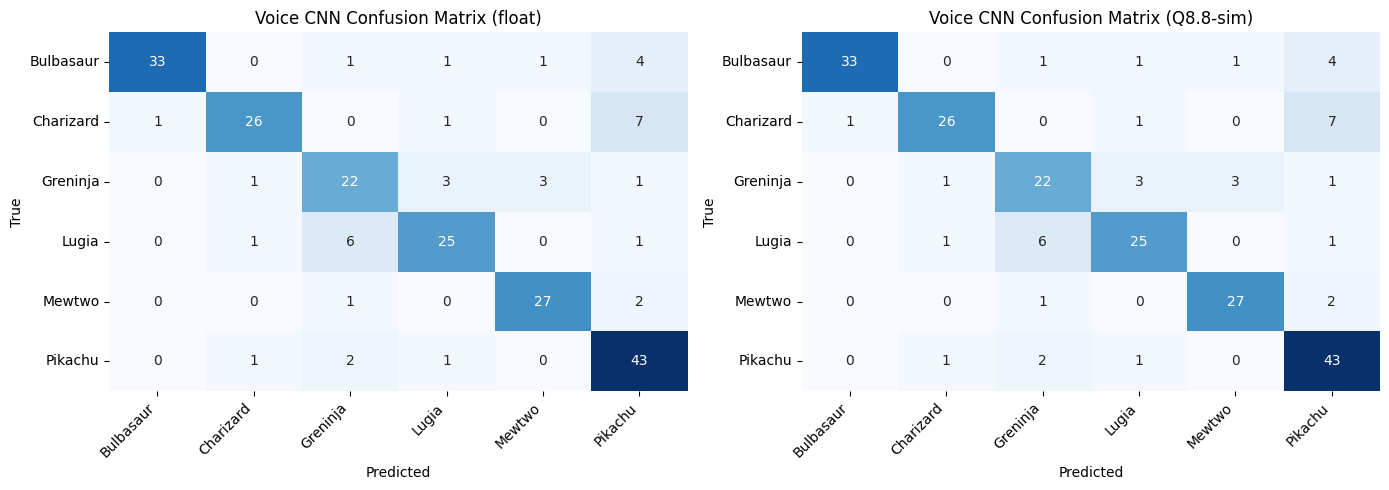

In [24]:
# Model input to forward(): [B, 40, 50] (MFCC channels-first).
# Training uses BatchNorm, focal weighting, and source-aware sampling.
# The deployed variant can then be fused back into the current HLS 2-conv export layout.


def print_model_summary(model, sample_input):
    rows, hooks = [], []

    def hook_fn(module, inputs, outputs):
        out = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
        out_shape = tuple(out.shape) if isinstance(out, torch.Tensor) else str(type(out))
        params = sum(p.numel() for p in module.parameters(recurse=False))
        rows.append((module.__class__.__name__, out_shape, params))

    for module in model.modules():
        if module is model or len(list(module.children())) > 0:
            continue
        hooks.append(module.register_forward_hook(hook_fn))

    was_training = model.training
    model.eval()
    with torch.no_grad():
        _ = model(sample_input)
    for hook in hooks:
        hook.remove()
    if was_training:
        model.train()

    print('Layer (type)       Output Shape        Param #')
    print('================================================')
    for name, shape, params in rows:
        print(f'{name:<18} {str(shape):<18} {params:,}')
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('================================================')
    print(f'Total params: {total_params:,}')
    print(f'Trainable params: {trainable_params:,}')
    print(f'Non-trainable params: {total_params - trainable_params:,}')


model = build_voice_model(
    NUM_CLASSES,
    variant=MODEL_VARIANT,
    dropout_p=DROPOUT_P,
    bn_momentum=BN_MOMENTUM,
    bn_eps=BN_EPS,
).to(device)
DEPLOYMENT_COMPATIBLE_MODEL = is_hls_shape_compatible_model(model)
print('Model variant:', MODEL_VARIANT)
print('HLS export target:', f'hls/{VOICE_HLS_SUBDIR}')
print('Deployment-compatible shape:', DEPLOYMENT_COMPATIBLE_MODEL)
if DEPLOYMENT_COMPATIBLE_MODEL:
    assert_hls_state_shapes(build_hls_export_state_dict(model), NUM_CLASSES, variant=MODEL_VARIANT)
    print('Model summary (training-time model with fused-export compatibility):')
else:
    assert_hls_state_shapes(build_hls_export_state_dict(model), NUM_CLASSES, variant=MODEL_VARIANT)
    print('Model summary (experimental 2-conv variant; exported to hls/voice_new and kept separate from the deployed HLS IP):')
print_model_summary(model, torch.zeros(1, 40, 50, device=device))

if LOSS_CLASS_WEIGHT_POWER > 0:
    loss_class_weights = np.power(class_weights, LOSS_CLASS_WEIGHT_POWER).astype(np.float32)
    loss_class_weights = loss_class_weights / loss_class_weights.mean()
    criterion_weight = torch.tensor(loss_class_weights, dtype=torch.float32, device=device)
    print('Loss class weights:', {ACTIVE_LABELS[i]: round(float(loss_class_weights[i]), 3) for i in range(NUM_CLASSES)})
else:
    criterion_weight = None
    print('Loss class weights: disabled (sampler handles imbalance)')

print('Focal gamma:', FOCAL_GAMMA)
print('Mixup alpha:', MIXUP_ALPHA)
print('Label smoothing:', LABEL_SMOOTHING)
criterion = FocalCrossEntropyLoss(
    gamma=FOCAL_GAMMA,
    weight=criterion_weight,
    label_smoothing=LABEL_SMOOTHING,
)


def evaluate_loader(model, loader, quantize_q88=False):
    # quantize_q88=True only quantises input tensor; model weights remain float here.
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            x = xb.to(device)
            yb = yb.to(device)
            if quantize_q88:
                x = torch.clamp(torch.round(x * 256.0), -32768, 32767) / 256.0
            pred = torch.argmax(model(x), dim=1)
            y_true.extend(yb.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)

# Active training loop: feature-domain augmentation + focal loss + source-aware sampling.
best_val = -1.0
best_epoch = 0
best_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0
print(f'Start training for {EPOCHS} epochs...')
for ep in range(EPOCHS):
    model.train()
    run_loss, corr, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()

        xb_mix, y_a, y_b, lam = mixup_batch(xb, yb, MIXUP_ALPHA)
        out = model(xb_mix)
        loss = lam * criterion(out, y_a) + (1.0 - lam) * criterion(out, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        run_loss += loss.item()
        pred = torch.argmax(out, dim=1)
        hard_target = y_a if lam >= 0.5 else y_b
        corr += (pred == hard_target).sum().item()
        total += yb.size(0)

    tr_acc = 100.0 * corr / max(total, 1)
    val_acc, _, _ = evaluate_loader(model, val_loader, quantize_q88=False)
    scheduler.step(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_epoch = ep + 1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if PRINT_EVERY_EPOCH or ep == 0 or (ep + 1) % 5 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(
            f'Epoch {ep+1}/{EPOCHS} | '
            f'Loss {run_loss/max(len(train_loader),1):.4f} | '
            f'Train {tr_acc:.2f}% | Val {val_acc:.2f}% | LR {lr:.6f}'
        )

    if EARLY_STOPPING_PATIENCE is not None and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {ep+1}; best val acc remains {best_val:.2f}%')
        break

model.load_state_dict(best_state)
dashboard_checkpoint = {
    'variant': MODEL_VARIANT,
    'num_classes': NUM_CLASSES,
    'dropout_p': DROPOUT_P,
    'bn_momentum': BN_MOMENTUM,
    'bn_eps': BN_EPS,
    'labels': ACTIVE_LABELS,
    'preprocess_config': VOICE_PREPROCESS_KWARGS,
    'state_dict': {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()},
}
torch.save(dashboard_checkpoint, VOICE_DASHBOARD_CHECKPOINT_PT)
print(f'Best val acc: {best_val:.2f}% at epoch {best_epoch}')
print('Saved dashboard checkpoint:', VOICE_DASHBOARD_CHECKPOINT_PT)

# Float + simple Q8.8 input simulation
float_acc, y_true, y_pred = evaluate_loader(model, test_loader, quantize_q88=False)
q88_acc, y_true_q, y_pred_q = evaluate_loader(model, test_loader, quantize_q88=True)
test_predictions_df = manifest_df.iloc[test_idx].reset_index().rename(columns={'index': 'manifest_idx'}).copy()
test_predictions_df['true_id'] = np.asarray(y_true, dtype=np.int64)
test_predictions_df['pred_id'] = np.asarray(y_pred, dtype=np.int64)
test_predictions_df['true_label'] = [ACTIVE_LABELS[int(idx)] for idx in y_true]
test_predictions_df['pred_label'] = [ACTIVE_LABELS[int(idx)] for idx in y_pred]
test_predictions_df['q88_pred_id'] = np.asarray(y_pred_q, dtype=np.int64)
test_predictions_df['q88_pred_label'] = [ACTIVE_LABELS[int(idx)] for idx in y_pred_q]
test_predictions_df['is_correct'] = test_predictions_df['true_id'] == test_predictions_df['pred_id']
test_predictions_df['split_seed'] = split_seed
test_predictions_df['model_variant'] = MODEL_VARIANT
test_predictions_df.to_csv(TEST_PREDICTIONS_CSV, index=False)
print('Saved test predictions:', TEST_PREDICTIONS_CSV)
print(f'Final Test Accuracy (float): {float_acc:.2f}%')
print(f'Final Test Accuracy (Q8.8-sim): {q88_acc:.2f}%')

cm_float = confusion_matrix(y_true, y_pred)
cm_q88 = confusion_matrix(y_true_q, y_pred_q)
labels = ACTIVE_LABELS if len(ACTIVE_LABELS) == cm_float.shape[0] else [str(i) for i in range(cm_float.shape[0])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_float, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Voice CNN Confusion Matrix (float)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_yticklabels(labels, rotation=0)

sns.heatmap(cm_q88, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Voice CNN Confusion Matrix (Q8.8-sim)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].set_yticklabels(labels, rotation=0)
plt.tight_layout()
plt.show()


## 5) HLS-like and deployment-equivalent fixed-point checks


In [25]:
Q88_MIN = -128.0
Q88_MAX = 127.99609375
Q88_SCALE = 256.0


def q88_ap_trn_sat(x: torch.Tensor) -> torch.Tensor:
    # Mimics ap_fixed<16,8, AP_TRN, AP_SAT>: truncate fractional bits and saturate range.
    y = torch.clamp(x, Q88_MIN, Q88_MAX)
    y = torch.trunc(y * Q88_SCALE) / Q88_SCALE
    return y


def q88_axis_ingress(x: torch.Tensor) -> torch.Tensor:
    # Mimics ultra96/deployment/hardware.py:q88_pack_u32, which rounds at the software-to-AXIS boundary.
    y = torch.clamp(x, Q88_MIN, Q88_MAX)
    y = torch.round(y * Q88_SCALE) / Q88_SCALE
    return y


def state_dict_to_device(sd: dict[str, torch.Tensor], target_device: torch.device) -> dict[str, torch.Tensor]:
    return {name: tensor.to(target_device) for name, tensor in sd.items()}


@torch.no_grad()
def hls_like_forward_from_state(sd: dict, x: torch.Tensor) -> torch.Tensor:
    # Mirrors the selected 2-conv HLS voice core: conv1 -> relu -> maxpool -> conv2 -> relu -> global avg -> fc.
    sd = state_dict_to_device(sd, x.device)
    w1 = q88_ap_trn_sat(sd['conv1.weight'])
    b1 = q88_ap_trn_sat(sd['conv1.bias'])
    w2 = q88_ap_trn_sat(sd['conv2.weight'])
    b2 = q88_ap_trn_sat(sd['conv2.bias'])
    wf = q88_ap_trn_sat(sd['fc.weight'])
    bf = q88_ap_trn_sat(sd['fc.bias'])

    xq = q88_axis_ingress(x)
    xq = q88_ap_trn_sat(F.conv1d(xq, w1, b1, stride=1, padding=1))
    xq = q88_ap_trn_sat(F.relu(xq))
    xq = q88_ap_trn_sat(F.max_pool1d(xq, kernel_size=2))
    xq = q88_ap_trn_sat(F.conv1d(xq, w2, b2, stride=1, padding=1))
    xq = q88_ap_trn_sat(F.relu(xq))
    xq = q88_ap_trn_sat(F.adaptive_avg_pool1d(xq, 1))
    xq = q88_ap_trn_sat(F.linear(xq.squeeze(-1), wf, bf))
    return xq


@torch.no_grad()
def evaluate_loader_hls_like(sd: dict, loader):
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = torch.argmax(hls_like_forward_from_state(sd, xb), dim=1)
        y_true.extend(yb.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


hls_state = build_hls_export_state_dict(model)
if DEPLOYMENT_COMPATIBLE_MODEL:
    assert_hls_state_shapes(hls_state, NUM_CLASSES, variant=MODEL_VARIANT)
    print('Fused BatchNorm into conv layers for HLS-equivalent evaluation.')
else:
    assert_hls_state_shapes(hls_state, NUM_CLASSES, variant=MODEL_VARIANT)
    print('Built fused 2-conv state dict for experimental fixed-point simulation and hls/voice_new export.')

hls_like_acc, y_true_hls, y_pred_hls = evaluate_loader_hls_like(hls_state, test_loader)
if DEPLOYMENT_COMPATIBLE_MODEL:
    print(f'HLS-like Test Accuracy (Q8.8 layer-wise sim): {hls_like_acc:.2f}%')
else:
    print(f'Experimental variant fixed-point Accuracy (Q8.8 layer-wise sim): {hls_like_acc:.2f}%')


# Experimental path only: fold dataset z-score normalization into conv1 for raw-input tests.
def build_fused_state_dict_for_raw_input(sd_base: dict, mean_40: np.ndarray, std_40: np.ndarray):
    sd = {k: v.detach().cpu().clone() for k, v in sd_base.items()}
    w_key, b_key = 'conv1.weight', 'conv1.bias'
    mean_t = torch.as_tensor(mean_40, dtype=sd[w_key].dtype).reshape(1, -1, 1)
    std_t = torch.as_tensor(std_40, dtype=sd[w_key].dtype).reshape(1, -1, 1)
    if torch.any(std_t == 0):
        raise ValueError('std contains zero; cannot fuse normalization')
    sd[w_key] = sd[w_key] * (1.0 / std_t)
    sd[b_key] = sd[b_key] - (sd[w_key] * mean_t).sum(dim=(1, 2))
    return sd


@torch.no_grad()
def evaluate_runtime_aligned_voice_hls_like(
    sd: dict,
    X_raw: np.ndarray,
    y_true_np: np.ndarray,
    mean_40: np.ndarray,
    std_40: np.ndarray,
    batch_size=256,
):
    mean = mean_40.astype(np.float32).reshape(1, -1, 1)
    std = std_40.astype(np.float32).reshape(1, -1, 1)
    X_norm = ((X_raw.astype(np.float32) - mean) / std).astype(np.float32)
    X_t = torch.tensor(X_norm, dtype=torch.float32)
    y_t = torch.tensor(y_true_np.astype(np.int64), dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = torch.argmax(hls_like_forward_from_state(sd, xb), dim=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


@torch.no_grad()
def evaluate_raw_board_hls_like(sd_fused: dict, X_raw: np.ndarray, y_true_np: np.ndarray, batch_size=256):
    X_t = torch.tensor(X_raw, dtype=torch.float32)
    y_t = torch.tensor(y_true_np.astype(np.int64), dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        pred = torch.argmax(hls_like_forward_from_state(sd_fused, xb), dim=1)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())
    return 100.0 * accuracy_score(y_true, y_pred), y_true, y_pred


# Runtime-aligned check: raw MFCC -> software z-score -> Q8.8 ingress -> non-fused exported weights.
X_board_raw = np.load(BOARD_TEST_NPY).astype(np.float32)
y_board = np.load(YTEST_NPY).astype(np.int64).reshape(-1)
mean_40 = np.load(MEAN_NPY).astype(np.float32).reshape(-1)
std_40 = np.load(STD_NPY).astype(np.float32).reshape(-1)

n = min(len(X_board_raw), len(y_board))
X_board_raw = X_board_raw[:n]
y_board = y_board[:n]

runtime_acc, _, _ = evaluate_runtime_aligned_voice_hls_like(hls_state, X_board_raw, y_board, mean_40, std_40)
if DEPLOYMENT_COMPATIBLE_MODEL:
    print(f'Runtime-aligned Accuracy (raw -> z-score -> Q8.8 layer-wise): {runtime_acc:.2f}%')
else:
    print(f'Experimental variant runtime-aligned Accuracy (raw -> z-score -> Q8.8 layer-wise): {runtime_acc:.2f}%')

# Optional experiment: raw MFCC straight into the core with z-score fused into conv1.
sd_fused = build_fused_state_dict_for_raw_input(hls_state, mean_40, std_40)
deploy_acc, _, _ = evaluate_raw_board_hls_like(sd_fused, X_board_raw, y_board)
print(f'Experimental fused-input Accuracy (raw + fused-conv1 + Q8.8 layer-wise): {deploy_acc:.2f}%')


Built fused 2-conv state dict for experimental fixed-point simulation and hls/voice_new export.
Experimental variant fixed-point Accuracy (Q8.8 layer-wise sim): 82.79%
Experimental variant runtime-aligned Accuracy (raw -> z-score -> Q8.8 layer-wise): 82.79%
Experimental fused-input Accuracy (raw + fused-conv1 + Q8.8 layer-wise): 81.40%


## 6) Export weights (software normalization path)


In [26]:
EXPERIMENTAL_MODEL_EXPORT_WARNING = (
    'This export keeps the deployed and experimental HLS voice headers separate. '
    'The deployed 16/32-channel model goes to hls/voice, while the experimental 20/40-channel model goes to hls/voice_new.'
)


def export_pytorch_weights(model, filename=WEIGHTS_H_PATH, fuse_input_norm=False, norm_mean=None, norm_std=None, variant=MODEL_VARIANT):
    # Emit flattened tensors to a C header consumed directly by Vitis HLS C++ code.
    print(f'Exporting weights to {filename}...')
    print(EXPERIMENTAL_MODEL_EXPORT_WARNING)
    params = build_hls_export_state_dict(model)
    assert_hls_state_shapes(params, NUM_CLASSES, variant=variant)
    print('Fused BatchNorm into conv layers for export.')

    # Optional fusion path kept for experiments only.
    # The active deployment path applies MFCC z-score normalization in software,
    # so the exported HLS weights should remain non-fused.
    if fuse_input_norm:
        if norm_mean is None or norm_std is None:
            raise ValueError('norm_mean and norm_std are required when fuse_input_norm=True')

        w_key, b_key = 'conv1.weight', 'conv1.bias'
        mean_t = torch.as_tensor(norm_mean, dtype=params[w_key].dtype)
        std_t = torch.as_tensor(norm_std, dtype=params[w_key].dtype)

        if mean_t.numel() != params[w_key].shape[1] or std_t.numel() != params[w_key].shape[1]:
            raise ValueError('mean/std channel count mismatch')
        if torch.any(std_t == 0):
            raise ValueError('std contains zero; cannot fuse normalization')

        params[w_key] = params[w_key] * (1.0 / std_t).view(1, -1, 1)
        params[b_key] = params[b_key] - (params[w_key] * mean_t.view(1, -1, 1)).sum(dim=(1, 2))
        print('Fused z-score normalization into conv1 for raw-input inference.')

    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)
    with open(filename, 'w') as f:
        f.write('#ifndef VOICE_CNN_WEIGHTS_H\n#define VOICE_CNN_WEIGHTS_H\n\n')
        f.write('#include "voice_typedefs.h"\n\n')

        total_params = 0
        for name, tensor in params.items():
            clean_name = name.replace('.', '_').replace('weight', 'w').replace('bias', 'b')
            data = tensor.numpy().flatten()
            total_params += len(data)

            f.write(f'// PyTorch Layer: {name} (Shape: {tuple(tensor.shape)})\n')
            f.write(f'static const data_t {clean_name}[{len(data)}] = {{\n')
            for i, val in enumerate(data):
                f.write(f'{val:.6f}')
                if i < len(data) - 1:
                    f.write(', ')
                if (i + 1) % 10 == 0:
                    f.write('\n    ')
            f.write('\n};\n\n')

        f.write('#endif // VOICE_CNN_WEIGHTS_H\n')

    print(f'Done! Total parameters: {total_params}')


export_pytorch_weights(
    model,
    WEIGHTS_H_PATH,
    fuse_input_norm=False,
    norm_mean=np.load(MEAN_NPY),
    norm_std=np.load(STD_NPY),
    variant=MODEL_VARIANT,
)
save_voice_labels(ACTIVE_LABELS, LABELS_JSON)
save_voice_preprocess_config(VOICE_PREPROCESS_KWARGS, PREPROCESS_CONFIG_JSON)
print('Saved runtime metadata:', LABELS_JSON, PREPROCESS_CONFIG_JSON)

# Also export to the variant-specific HLS voice folder.
repo_root = Path.cwd().resolve()
for p in [repo_root, *repo_root.parents]:
    if (p / 'hls').exists():
        repo_root = p
        break

hls_voice_dir = repo_root / 'hls' / VOICE_HLS_SUBDIR
hls_voice_dir.mkdir(parents=True, exist_ok=True)
hls_voice_weights = hls_voice_dir / 'voice_cnn_weights.h'

if Path(WEIGHTS_H_PATH).resolve() != hls_voice_weights.resolve():
    export_pytorch_weights(
        model,
        hls_voice_weights,
        fuse_input_norm=False,
        norm_mean=np.load(MEAN_NPY),
        norm_std=np.load(STD_NPY),
        variant=MODEL_VARIANT,
    )
else:
    print('HLS voice weights path matches primary export; skipped duplicate export.')

hls_voice_labels = hls_voice_dir / 'voice_labels.json'
hls_voice_preprocess = hls_voice_dir / 'voice_preprocess_config.json'
save_voice_labels(ACTIVE_LABELS, hls_voice_labels)
save_voice_preprocess_config(VOICE_PREPROCESS_KWARGS, hls_voice_preprocess)
print('Saved HLS runtime metadata:', hls_voice_labels, hls_voice_preprocess)


Exporting weights to ../data/audio/20260406_combined/voice_cnn_weights.h...
This export keeps the deployed and experimental HLS voice headers separate. The deployed 16/32-channel model goes to hls/voice, while the experimental 20/40-channel model goes to hls/voice_new.
Fused BatchNorm into conv layers for export.
Done! Total parameters: 5106
Saved runtime metadata: ../data/audio/20260406_combined/voice_labels.json ../data/audio/20260406_combined/voice_preprocess_config.json
Exporting weights to /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/voice_new/voice_cnn_weights.h...
This export keeps the deployed and experimental HLS voice headers separate. The deployed 16/32-channel model goes to hls/voice, while the experimental 20/40-channel model goes to hls/voice_new.
Fused BatchNorm into conv layers for export.
Done! Total parameters: 5106
Saved HLS runtime metadata: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/voice_new/voice_labels.json /Users/luozhiyang/Projects/CG4002-Cod

In [27]:
# Inspect misclassified test audio.
from html import escape
from pathlib import Path

from IPython.display import Audio, display

from voice_feature_pipeline import decode_audio_file

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

# Controls: adjust these before re-running the cell.
MAX_ROWS_TO_SHOW = 10
START_ROW = 0
SHOW_AUDIO_PLAYERS = True
RENDER_INTERACTIVE_REVIEW = True
DELETE_LOG_CSV = ARTIFACT_AUDIO_DIR / 'deleted_test_audio_log.csv' if 'ARTIFACT_AUDIO_DIR' in globals() else Path('deleted_test_audio_log.csv')

if 'y_true' not in globals() or 'y_pred' not in globals():
    raise RuntimeError('Run the training/evaluation cell first so y_true and y_pred are available.')

id_to_label = {int(v): str(k) for k, v in CLASS_MAP.items()} if 'CLASS_MAP' in globals() else {}
records = []
for local_idx, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if int(yt) == int(yp):
        continue

    manifest_idx = None
    if 'test_idx' in globals():
        try:
            manifest_idx = int(test_idx[local_idx])
        except Exception:
            manifest_idx = None

    rec = {
        'test_local_idx': int(local_idx),
        'manifest_idx': manifest_idx,
        'true_id': int(yt),
        'pred_id': int(yp),
        'true_label': id_to_label.get(int(yt), int(yt)),
        'pred_label': id_to_label.get(int(yp), int(yp)),
    }

    if manifest_idx is not None and 'manifest_df' in globals() and 0 <= manifest_idx < len(manifest_df):
        row = manifest_df.iloc[manifest_idx]
        for col in ['path', 'label', 'speaker_id', 'utterance_id']:
            if col in manifest_df.columns:
                rec[col] = row[col]

    records.append(rec)

mis_df = pd.DataFrame(records)


def append_deleted_audio_log(row_payload, log_csv=DELETE_LOG_CSV):
    log_csv = Path(log_csv)
    log_csv.parent.mkdir(parents=True, exist_ok=True)
    log_row = {
        'deleted_at': pd.Timestamp.now().isoformat(timespec='seconds'),
        'test_local_idx': row_payload.get('test_local_idx'),
        'manifest_idx': row_payload.get('manifest_idx'),
        'true_label': row_payload.get('true_label'),
        'pred_label': row_payload.get('pred_label'),
        'label': row_payload.get('label'),
        'speaker_id': row_payload.get('speaker_id'),
        'utterance_id': row_payload.get('utterance_id'),
        'path': row_payload.get('path'),
    }
    new_log_df = pd.DataFrame([log_row])
    if log_csv.exists():
        existing_log_df = pd.read_csv(log_csv)
        new_log_df = pd.concat([existing_log_df, new_log_df], ignore_index=True)
    new_log_df.to_csv(log_csv, index=False)
    return log_csv


def unlink_audio_row(row_payload, status_widget=None, button_widget=None, log_csv=DELETE_LOG_CSV):
    audio_path_str = str(row_payload.get('path', '')).strip()
    if not audio_path_str:
        if status_widget is not None:
            status_widget.value = '<span style="color:#b54708;">No file path available.</span>'
        return False

    audio_path = Path(audio_path_str)

    if not audio_path.exists():
        if button_widget is not None:
            button_widget.disabled = True
            button_widget.description = 'Missing'
        if status_widget is not None:
            status_widget.value = f'<span style="color:#b54708;">File already missing: {escape(str(audio_path))}</span>'
        return False

    audio_path.unlink()
    log_csv = append_deleted_audio_log(row_payload, log_csv=log_csv)
    if button_widget is not None:
        button_widget.disabled = True
        button_widget.description = 'Deleted'
        button_widget.button_style = ''
        button_widget.icon = 'check'
    if status_widget is not None:
        status_widget.value = (
            f'<span style="color:#027a48;">Deleted. Logged to {escape(str(log_csv))}. '
            'Re-run from the manifest/features cell onwards to rebuild without this clip.</span>'
        )
    return True


def render_interactive_review(rows_df, show_audio_players=True):
    if widgets is None:
        print('ipywidgets is not available in this kernel, so interactive delete buttons cannot be shown here.')
        return

    cards = []
    for _, row in rows_df.iterrows():
        row_payload = row.to_dict()
        audio_path = Path(str(row_payload.get('path', '')))
        header = widgets.HTML(
            value=(
                f"<b>Row {int(row_payload['visible_row_idx'])}</b> | "
                f"true={escape(str(row_payload['true_label']))} | "
                f"pred={escape(str(row_payload['pred_label']))} | "
                f"manifest_idx={escape(str(row_payload['manifest_idx']))}"
            )
        )
        details = widgets.HTML(
            value=(
                f"speaker={escape(str(row_payload.get('speaker_id', '')))} | "
                f"utterance={escape(str(row_payload.get('utterance_id', '')))}<br>"
                f"<code>{escape(str(audio_path))}</code>"
            )
        )
        status = widgets.HTML(value='')
        delete_button = widgets.Button(description='Delete clip', button_style='danger', icon='trash')
        if not audio_path.exists():
            delete_button.disabled = True
            delete_button.description = 'Missing'
            status.value = '<span style="color:#b54708;">File already missing on disk.</span>'

        def _handle_delete(_button, row_payload=row_payload, status=status, delete_button=delete_button):
            unlink_audio_row(row_payload, status_widget=status, button_widget=delete_button)

        delete_button.on_click(_handle_delete)
        controls = [delete_button, status]
        children = [header, details]

        if show_audio_players and audio_path.exists():
            play_button = widgets.Button(description='Load audio', button_style='info', icon='play')
            audio_out = widgets.Output()

            def _handle_play(_button, audio_path=audio_path, audio_out=audio_out):
                with audio_out:
                    audio_out.clear_output(wait=True)
                    try:
                        waveform = decode_audio_file(audio_path, sample_rate=SAMPLE_RATE)
                        display(Audio(data=waveform, rate=SAMPLE_RATE, autoplay=False))
                    except Exception as exc:
                        print(f'Could not play audio: {exc}')

            play_button.on_click(_handle_play)
            controls.insert(0, play_button)
            children.append(audio_out)

        controls = widgets.HBox(controls)
        children.insert(2, controls)

        card = widgets.VBox(
            children,
            layout=widgets.Layout(border='1px solid #d0d5dd', padding='10px', margin='0 0 10px 0'),
        )
        cards.append(card)

    display(widgets.VBox(cards))
print(f'Misclassified samples: {len(mis_df)} / {len(y_true)}')

if mis_df.empty:
    print('No misclassified samples in this test run.')
else:
    visible_df = mis_df.iloc[START_ROW:START_ROW + MAX_ROWS_TO_SHOW].reset_index(drop=True).copy()
    visible_df.insert(0, 'visible_row_idx', np.arange(START_ROW, START_ROW + len(visible_df)))
    summary_cols = [
        col for col in ['visible_row_idx', 'test_local_idx', 'manifest_idx', 'true_label', 'pred_label', 'speaker_id', 'utterance_id', 'path']
        if col in visible_df.columns
    ]
    display(visible_df[summary_cols])
    if RENDER_INTERACTIVE_REVIEW:
        render_interactive_review(visible_df, show_audio_players=SHOW_AUDIO_PLAYERS)
    else:
        print('Interactive review is disabled. Set RENDER_INTERACTIVE_REVIEW = True to show delete buttons.')


Misclassified samples: 39 / 215


,visible_row_idx,test_local_idx,manifest_idx,true_label,pred_label,speaker_id,utterance_id,path
0,0,1,883,pikachu,lugia,old_speaker_002,3,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
1,1,2,644,lugia,pikachu,voice_speaker_002,2,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
2,2,3,100,bulbasaur,lugia,synthetic_speaker_002,2,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
3,3,7,416,greninja,pikachu,synthetic_speaker_002,2,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
4,4,8,268,charizard,pikachu,old_speaker_007,1,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
5,5,13,606,lugia,greninja,voice_speaker_001,2,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
6,6,32,21,bulbasaur,pikachu,new_qyl,1,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
7,7,44,410,greninja,lugia,synthetic_speaker_001,1,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
8,8,59,33,bulbasaur,greninja,new_syj,3,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...
9,9,67,252,charizard,pikachu,old_speaker_003,5,/Users/luozhiyang/Projects/CG4002-Code/CG4002-...


In [28]:
# Generate HLS voice testbench cases header from saved test arrays.
import subprocess
import sys
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'hls').exists():
            return p
    raise FileNotFoundError(f"Could not find hls/ from cwd={cwd}")


def _find_voice_gen_script(repo_root: Path) -> Path:
    candidates = [
        repo_root / 'tools' / 'gen_voice_tb_cases.py',
        repo_root / 'hls' / 'voice' / 'gen_voice_tb_cases.py',
        repo_root / 'hls' / 'gen_voice_tb_cases.py',  # backward-compatible fallback
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError('Could not find voice generator script under hls/.')


def _resolve_voice_npy() -> tuple[Path, Path]:
    fx, fy = Path(TEST_NORM_NPY), Path(YTEST_NPY)
    if not fx.exists() or not fy.exists():
        raise FileNotFoundError(
            f'Selected voice HLS test arrays are missing: {fx} and {fy}. '
            'Run the notebook from the active dataset path-selection cell downward.'
        )
    return fx.resolve(), fy.resolve()


repo_root = _repo_root()
gen_script = _find_voice_gen_script(repo_root)
features_npy, labels_npy = _resolve_voice_npy()
out_h = (repo_root / 'hls' / VOICE_HLS_SUBDIR / 'voice_tb_cases.h').resolve()

tb_cases = int(globals().get('VOICE_TB_NUM_CASES', 300))
tb_seed = int(globals().get('VOICE_TB_SEED', 42))

cmd = [
    sys.executable,
    str(gen_script),
    '--features', str(features_npy),
    '--labels', str(labels_npy),
    '--out', str(out_h),
    '--num-cases', str(tb_cases),
    '--seed', str(tb_seed),
]

print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True, cwd=repo_root)
print('Generated:', out_h)


Running: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/.venv/bin/python /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/tools/gen_voice_tb_cases.py --features /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/audio/20260406_combined/voice_X_test_norm.npy --labels /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/audio/20260406_combined/voice_y_test.npy --out /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/voice_new/voice_tb_cases.h --num-cases 300 --seed 42
Wrote /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/voice_new/voice_tb_cases.h with 105 cases. Label distribution: 0:40, 1:35, 2:30
Generated: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/hls/voice_new/voice_tb_cases.h


In [29]:
# Sync voice test artefacts into ultra96/local-ai-test.
import shutil
from pathlib import Path


def _repo_root_with_ultra96() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'ultra96').exists():
            return p
    raise FileNotFoundError(f"Could not find ultra96/ from cwd={cwd}")


def _resolve_voice_test_artifacts() -> tuple[Path, Path, Path]:
    norm_p, raw_p, y_p = Path(TEST_NORM_NPY), Path(BOARD_TEST_NPY), Path(YTEST_NPY)
    if not norm_p.exists() or not raw_p.exists() or not y_p.exists():
        raise FileNotFoundError(
            f'Selected voice test artefacts are missing: {norm_p}, {raw_p}, {y_p}. '
            'Run the notebook from the active dataset path-selection cell downward.'
        )
    return norm_p.resolve(), raw_p.resolve(), y_p.resolve()


repo_root = _repo_root_with_ultra96()
norm_features_npy, raw_features_npy, labels_npy = _resolve_voice_test_artifacts()

ultra96_dir = Path(globals().get('ULTRA96_DIR', repo_root / 'ultra96' / 'local-ai-test')).resolve()
ultra96_dir.mkdir(parents=True, exist_ok=True)
ultra96_deploy_dir = (repo_root / 'ultra96' / 'deployment').resolve()
ultra96_deploy_dir.mkdir(parents=True, exist_ok=True)

dst_x = ultra96_dir / 'voice_X_test.npy'
dst_x_raw = ultra96_dir / 'voice_X_test_raw.npy'
dst_y = ultra96_dir / 'voice_y_test.npy'
dst_mean = ultra96_deploy_dir / 'voice_mean.npy'
dst_std = ultra96_deploy_dir / 'voice_std.npy'
dst_labels_meta = ultra96_deploy_dir / 'voice_labels.json'
dst_preprocess_meta = ultra96_deploy_dir / 'voice_preprocess_config.json'

shutil.copy2(norm_features_npy, dst_x)
shutil.copy2(raw_features_npy, dst_x_raw)
shutil.copy2(labels_npy, dst_y)
shutil.copy2(Path(MEAN_NPY), dst_mean)
shutil.copy2(Path(STD_NPY), dst_std)
shutil.copy2(Path(LABELS_JSON), dst_labels_meta)
shutil.copy2(Path(PREPROCESS_CONFIG_JSON), dst_preprocess_meta)

print('Copied voice test artefacts:')
print('  normalized:', norm_features_npy, '->', dst_x)
print('  raw:', raw_features_npy, '->', dst_x_raw)
print('  labels:', labels_npy, '->', dst_y)
print('  mean:', Path(MEAN_NPY), '->', dst_mean)
print('  std:', Path(STD_NPY), '->', dst_std)
print('  labels:', Path(LABELS_JSON), '->', dst_labels_meta)
print('  preprocess:', Path(PREPROCESS_CONFIG_JSON), '->', dst_preprocess_meta)


Copied voice test artefacts:
  normalized: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/audio/20260406_combined/voice_X_test_norm.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/local-ai-test/voice_X_test.npy
  raw: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/audio/20260406_combined/voice_X_test.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/local-ai-test/voice_X_test_raw.npy
  labels: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/data/audio/20260406_combined/voice_y_test.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/local-ai-test/voice_y_test.npy
  mean: ../data/audio/20260406_combined/voice_mean.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/deployment/voice_mean.npy
  std: ../data/audio/20260406_combined/voice_std.npy -> /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/ultra96/deployment/voice_std.npy
  labels: ../data/audio/20260406_combined/voice_labels.json -> /Users/luozhiyang/Projects/CG40

In [30]:
# Prepare repo-local export bundles for Windows HLS and Ultra96 handoff.
import shutil
from pathlib import Path


def _repo_root_with_hls() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'hls').exists() and (p / 'ultra96').exists():
            return p
    raise FileNotFoundError(f"Could not find repo root with hls/ and ultra96/ from cwd={cwd}")


def _copy_files(files, dst_dir: Path) -> int:
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = 0
    for src in files:
        src_path = Path(src)
        if not src_path.exists() or not src_path.is_file():
            continue
        shutil.copy2(src_path, dst_dir / src_path.name)
        copied += 1
    return copied


repo_root = _repo_root_with_hls()
export_root = Path(globals().get('EXPORT_ROOT', repo_root / 'exports')).resolve()
hls_voice_dir = repo_root / 'hls' / VOICE_HLS_SUBDIR
ultra96_root = repo_root / 'ultra96'

voice_hls_export_dir = export_root / 'windows_hls' / VOICE_HLS_SUBDIR
ultra96_export_root = export_root / 'ultra96_runtime'
ultra96_local_export_dir = ultra96_export_root / 'ultra96' / 'local-ai-test'
ultra96_deploy_export_dir = ultra96_export_root / 'ultra96' / 'deployment'
ultra96_mqtt_export_dir = ultra96_export_root / 'ultra96' / 'mqtt-test'

voice_hls_files = [
    p for p in sorted(hls_voice_dir.iterdir())
    if p.is_file() and not (p.name.startswith('gen_') and p.suffix == '.py')
]
voice_local_files = [
    ultra96_root / 'local-ai-test' / 'dual_cnn_test.py',
    ultra96_root / 'local-ai-test' / 'run_assessment_suite.py',
    ultra96_root / 'local-ai-test' / 'voice_X_test.npy',
    ultra96_root / 'local-ai-test' / 'voice_X_test_raw.npy',
    ultra96_root / 'local-ai-test' / 'voice_y_test.npy',
]
voice_deploy_files = [
    ultra96_root / 'deployment' / 'audio.py',
    ultra96_root / 'deployment' / 'common.py',
    ultra96_root / 'deployment' / 'deployment.py',
    ultra96_root / 'deployment' / 'hardware.py',
    ultra96_root / 'deployment' / 'imu.py',
    ultra96_root / 'deployment' / 'messages.py',
    ultra96_root / 'deployment' / 'mqtt_ai_bridge.py',
    ultra96_root / 'deployment' / 'reconstruct.py',
    ultra96_root / 'deployment' / 'runtime.py',
    ultra96_root / 'deployment' / 'voice_mean.npy',
    ultra96_root / 'deployment' / 'voice_std.npy',
]
voice_mqtt_files = [
    ultra96_root / 'mqtt-test' / 'common.py',
    ultra96_root / 'mqtt-test' / 'self_test.py',
]
summary = {
    'voice_hls_files': _copy_files(voice_hls_files, voice_hls_export_dir),
    'voice_local_files': _copy_files(voice_local_files, ultra96_local_export_dir),
    'voice_deploy_files': _copy_files(voice_deploy_files, ultra96_deploy_export_dir),
    'voice_mqtt_files': _copy_files(voice_mqtt_files, ultra96_mqtt_export_dir),
}

print('Prepared repo-local voice export bundle:')
print('  HLS export:', voice_hls_export_dir)
print('  Ultra96 export root:', ultra96_export_root)
for key, value in summary.items():
    print(f'  {key}: {value}')
print('Copy dual_cnn.xsa manually into the deployment and local-ai-test folders on the target machine.')


Prepared repo-local voice export bundle:
  HLS export: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/exports/windows_hls/voice_new
  Ultra96 export root: /Users/luozhiyang/Projects/CG4002-Code/CG4002-AI/exports/ultra96_runtime
  voice_hls_files: 8
  voice_local_files: 5
  voice_deploy_files: 11
  voice_mqtt_files: 2
Copy dual_cnn.xsa manually into the deployment and local-ai-test folders on the target machine.
